In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from q_function_nn import QFunctionNN
import torch
from IPython.display import HTML
from matplotlib import animation

%load_ext autoreload
%autoreload 2

# Env 

In [4]:
# Init a built-in cartpole environment
env = gym.make("CartPole-v1", render_mode="rgb_array")

In [5]:
# There are only two actions for the cartpole
action_map = {0: 'push left', 1: 'push right'}

In [6]:
obs, info = env.reset()

In [7]:
obs

array([-0.03237701,  0.03827179, -0.00813125,  0.04069132], dtype=float32)

In [8]:
frame = env.render()

/home/eric/.cache/pypoetry/virtualenvs/rl-fundamental-iovhCHDa-py3.10/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate er

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

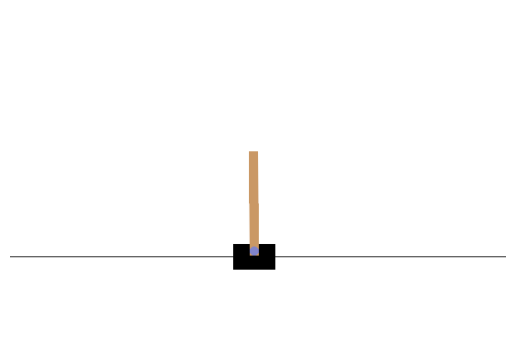

In [9]:
plt.imshow(frame)
plt.axis('off')

# Loss Function

$$L = r + \gamma(max Q(s^\prime) + Q(s, a))$$

# Comparison

In [10]:
# Cartpole with random actions
def random_cartpole(env, num_steps=500):
    frames = []
    obs, info = env.reset()
    steps = 0
    for _ in range(num_steps):
        steps += 1
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, steps

In [11]:
# Cartpole with trained DQL agent
def _get_action(q_function: QFunctionNN, obs):
    obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
    q_values = q_function(obs_tensor)
    action = torch.argmax(q_values).item()
    return action

def dql_cartpole(env, q_function: QFunctionNN, num_steps=500):
    frames = []
    obs, info = env.reset()
    steps = 0
    for _ in range(num_steps):
        steps += 1
        action = _get_action(q_function, obs)
        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, steps

In [12]:
# Start experiment
n_trials = 10
q_function = QFunctionNN(state_dim=4, action_dim=2)
# Load trained model
q_function.load_state_dict(torch.load("cartpole_policy_nn_v2.pth"))

<All keys matched successfully>

In [13]:
random_res = []
agent_res = []
for i in range(n_trials):
    print(f"Start trial {i}")
    random_frames, random_steps = random_cartpole(env)
    random_res.append({"n_steps": random_steps, "frames": random_frames})
    print(f"Random agent finished in {random_steps} steps")

    agent_frames, agent_steps = dql_cartpole(env, q_function)
    agent_res.append({"n_steps": agent_steps, "frames": agent_frames})
    print(f"DQL agent finished in {agent_steps} steps")

    print("-" * 30)

Start trial 0
Random agent finished in 34 steps
DQL agent finished in 500 steps
------------------------------
Start trial 1
Random agent finished in 13 steps
DQL agent finished in 500 steps
------------------------------
Start trial 2
Random agent finished in 36 steps
DQL agent finished in 500 steps
------------------------------
Start trial 3
Random agent finished in 26 steps
DQL agent finished in 117 steps
------------------------------
Start trial 4
Random agent finished in 27 steps
DQL agent finished in 500 steps
------------------------------
Start trial 5
Random agent finished in 19 steps
DQL agent finished in 500 steps
------------------------------
Start trial 6
Random agent finished in 26 steps
DQL agent finished in 500 steps
------------------------------
Start trial 7
Random agent finished in 23 steps
DQL agent finished in 240 steps
------------------------------
Start trial 8
Random agent finished in 17 steps
DQL agent finished in 500 steps
------------------------------
S

In [14]:
# Visualize frames
def show_animation(frames):
    def animate(i):
        im.set_array(frames[i])
        return [im]
        
    # Init a fig
    fig = plt.figure(figsize=(6, 4))
    plt.axis('off')
    im = plt.imshow(frames[0])

    # Add frames into animation
    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=1)

    return HTML(anim.to_jshtml())

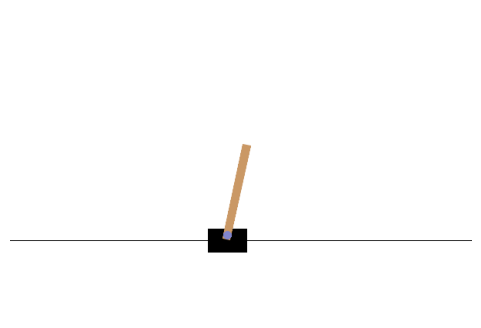

In [15]:
# Random trail # 4
show_animation(random_res[4]["frames"])

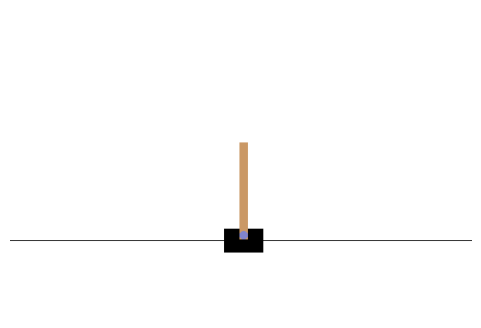

In [16]:
# Trained trail # 4
show_animation(agent_res[4]["frames"])